# Tutorial 12 — Basic Autoencoder

## Objective

This notebook implements **Tutorial 12: Basic Autoencoders** using PyTorch.

The tutorial covers:

- Loading and preprocessing the MNIST dataset
- Building a basic convolutional autoencoder
- Training the autoencoder to reconstruct images
- Visualizing original and reconstructed images
- Improving the autoencoder by changing the architecture

The main task is:

> Improve the autoencoder model by experimenting with different architectures to improve reconstruction quality.


## 1. Import Required Libraries

In [1]:
import os
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

os.makedirs("images", exist_ok=True)


PyTorch version: 2.5.1+cu121
CUDA available: True
Device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


## 2. Load and Preprocess the MNIST Dataset

The MNIST dataset contains grayscale handwritten digit images.

Each image has size:

\[
28 \times 28
\]

In PyTorch, `transforms.ToTensor()` automatically converts the pixel values from `0–255` to `0–1`.

For an autoencoder, the input and target are the same image:

\[
\text{input image} \rightarrow \text{encoder} \rightarrow \text{latent representation} \rightarrow \text{decoder} \rightarrow \text{reconstructed image}
\]


In [2]:
transform = transforms.ToTensor()

train_full_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

print("Training samples:", len(train_full_dataset))
print("Testing samples:", len(test_dataset))
print("Image shape:", train_full_dataset[0][0].shape)


Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting ./data\MNIST\raw\train-images-idx3-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting ./data\MNIST\raw\train-labels-idx1-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting ./data\MNIST\raw\t10k-images-idx3-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%

Extracting ./data\MNIST\raw\t10k-labels-idx1-ubyte.gz to ./data\MNIST\raw

Training samples: 60000
Testing samples: 10000
Image shape: torch.Size([1, 28, 28])


## 3. Create DataLoaders

To keep training time practical, the notebook uses a subset by default.

Set `USE_SUBSET = False` if you want to train on the full MNIST dataset.


In [3]:
USE_SUBSET = True
TRAIN_SUBSET_SIZE = 20000
TEST_SUBSET_SIZE = 5000

batch_size = 128

if USE_SUBSET:
    train_indices = np.arange(TRAIN_SUBSET_SIZE)
    test_indices = np.arange(TEST_SUBSET_SIZE)

    train_dataset = Subset(train_full_dataset, train_indices)
    test_dataset_used = Subset(test_dataset, test_indices)
else:
    train_dataset = train_full_dataset
    test_dataset_used = test_dataset

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset_used,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

print("Training samples used:", len(train_dataset))
print("Testing samples used:", len(test_dataset_used))


Training samples used: 20000
Testing samples used: 5000


## 4. Visualize Sample MNIST Images

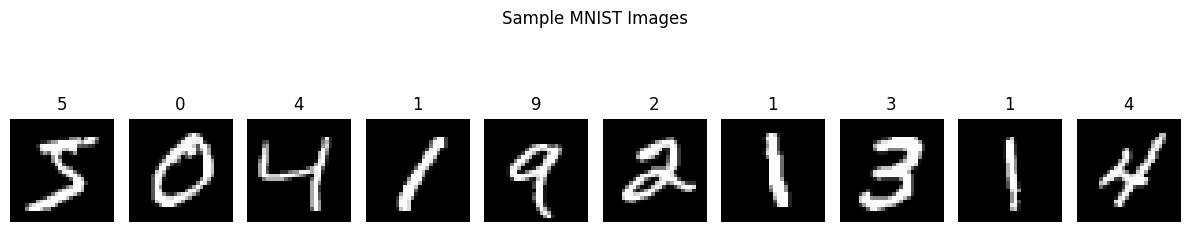

In [4]:
def show_mnist_samples(dataset, n_images=10):
    plt.figure(figsize=(12, 3))

    for i in range(n_images):
        image, label = dataset[i]
        plt.subplot(1, n_images, i + 1)
        plt.imshow(image.squeeze(), cmap="gray")
        plt.title(str(label))
        plt.axis("off")

    plt.suptitle("Sample MNIST Images")
    plt.tight_layout()
    plt.savefig("images/tutorial_12_mnist_samples.png", dpi=300, bbox_inches="tight")
    plt.show()


show_mnist_samples(train_full_dataset, n_images=10)


# Part A — Basic Convolutional Autoencoder

The autoencoder consists of two main parts:

## Encoder

The encoder compresses the input image into a smaller latent representation.

## Decoder

The decoder reconstructs the original image from the compressed representation.

The model is trained to minimize reconstruction error.


In [5]:
class BasicAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),   # 28x28 -> 14x14

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)    # 14x14 -> 7x7
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2),  # 7x7 -> 14x14
            nn.ReLU(),

            nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2),  # 14x14 -> 28x28
            nn.ReLU(),

            nn.Conv2d(16, 1, kernel_size=3, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded


basic_model = BasicAutoencoder().to(device)
print(basic_model)


BasicAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(64, 32, kernel_size=(2, 2), stride=(2, 2))
    (1): ReLU()
    (2): ConvTranspose2d(32, 16, kernel_size=(2, 2), stride=(2, 2))
    (3): ReLU()
    (4): Conv2d(16, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): Sigmoid()
  )
)


## 5. Training and Evaluation Functions

In [6]:
def train_autoencoder(model, train_loader, test_loader, epochs=5, learning_rate=0.001):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    history = {
        "train_loss": [],
        "test_loss": []
    }

    start_time = time.time()

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        train_total = 0

        for images, _ in train_loader:
            images = images.to(device)

            reconstructed = model(images)
            loss = criterion(reconstructed, images)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)
            train_total += images.size(0)

        train_loss = train_loss / train_total

        model.eval()
        test_loss = 0.0
        test_total = 0

        with torch.no_grad():
            for images, _ in test_loader:
                images = images.to(device)

                reconstructed = model(images)
                loss = criterion(reconstructed, images)

                test_loss += loss.item() * images.size(0)
                test_total += images.size(0)

        test_loss = test_loss / test_total

        history["train_loss"].append(train_loss)
        history["test_loss"].append(test_loss)

        print(
            f"Epoch {epoch + 1}/{epochs} | "
            f"Train Loss: {train_loss:.6f} | "
            f"Test Loss: {test_loss:.6f}"
        )

    total_time = time.time() - start_time

    return history, total_time


def plot_loss_curves(history, title, filename):
    epochs_range = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs_range, history["train_loss"], label="Train Loss")
    plt.plot(epochs_range, history["test_loss"], label="Test Loss")
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()


def visualize_reconstructions(model, dataset, filename, n_images=10):
    model.eval()

    plt.figure(figsize=(14, 4))

    with torch.no_grad():
        for i in range(n_images):
            image, _ = dataset[i]
            image_input = image.unsqueeze(0).to(device)
            reconstructed = model(image_input).cpu().squeeze()

            plt.subplot(2, n_images, i + 1)
            plt.imshow(image.squeeze(), cmap="gray")
            plt.title("Original")
            plt.axis("off")

            plt.subplot(2, n_images, i + 1 + n_images)
            plt.imshow(reconstructed, cmap="gray")
            plt.title("Reconstructed")
            plt.axis("off")

    plt.suptitle("Original vs Reconstructed Images")
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()


def count_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


## 6. Train the Basic Autoencoder

In [7]:
torch.manual_seed(SEED)

basic_model = BasicAutoencoder().to(device)

basic_history, basic_time = train_autoencoder(
    basic_model,
    train_loader,
    test_loader,
    epochs=5,
    learning_rate=0.001
)

print("Basic autoencoder training time:", round(basic_time, 2), "seconds")
print("Trainable parameters:", count_trainable_parameters(basic_model))


Epoch 1/5 | Train Loss: 0.086019 | Test Loss: 0.016652
Epoch 2/5 | Train Loss: 0.008980 | Test Loss: 0.006016
Epoch 3/5 | Train Loss: 0.005109 | Test Loss: 0.004516
Epoch 4/5 | Train Loss: 0.004166 | Test Loss: 0.003901
Epoch 5/5 | Train Loss: 0.003685 | Test Loss: 0.003528
Basic autoencoder training time: 16.68 seconds
Trainable parameters: 29249


## 7. Plot Basic Autoencoder Loss Curve

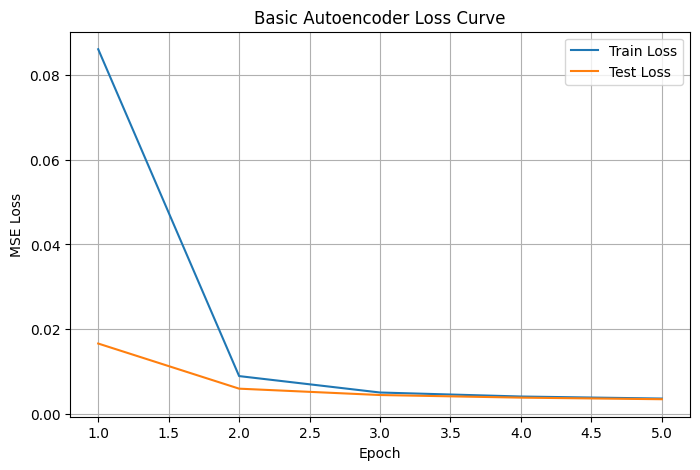

In [8]:
plot_loss_curves(
    basic_history,
    "Basic Autoencoder Loss Curve",
    "images/tutorial_12_basic_autoencoder_loss.png"
)


## 8. Visualize Basic Autoencoder Reconstructions

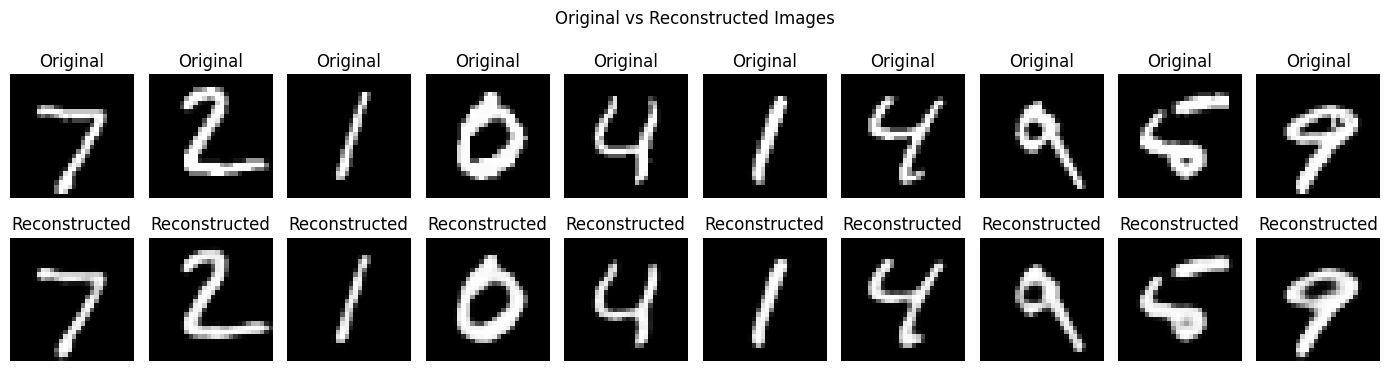

In [9]:
visualize_reconstructions(
    basic_model,
    test_dataset_used,
    filename="images/tutorial_12_basic_reconstructions.png",
    n_images=10
)


# Part B — Improved Autoencoder

The task asks to improve the model by experimenting with different architectures.

The improved model uses:

- More convolutional layers
- Batch normalization
- Larger number of channels
- A deeper encoder and decoder

The goal is to reduce reconstruction loss and improve visual reconstruction quality.


In [10]:
class ImprovedAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),   # 28x28 -> 14x14

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),   # 14x14 -> 7x7

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU()
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2),  # 7x7 -> 14x14
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2),   # 14x14 -> 28x28
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32, 16, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.Conv2d(16, 1, kernel_size=3, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded


improved_model = ImprovedAutoencoder().to(device)
print(improved_model)
print("Trainable parameters:", count_trainable_parameters(improved_model))


ImprovedAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU()
    (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), pa

## 9. Train the Improved Autoencoder

In [11]:
torch.manual_seed(SEED)

improved_model = ImprovedAutoencoder().to(device)

improved_history, improved_time = train_autoencoder(
    improved_model,
    train_loader,
    test_loader,
    epochs=5,
    learning_rate=0.001
)

print("Improved autoencoder training time:", round(improved_time, 2), "seconds")
print("Trainable parameters:", count_trainable_parameters(improved_model))


Epoch 1/5 | Train Loss: 0.023182 | Test Loss: 0.003905
Epoch 2/5 | Train Loss: 0.002327 | Test Loss: 0.002129
Epoch 3/5 | Train Loss: 0.001737 | Test Loss: 0.001620
Epoch 4/5 | Train Loss: 0.001482 | Test Loss: 0.002629
Epoch 5/5 | Train Loss: 0.001332 | Test Loss: 0.001256
Improved autoencoder training time: 19.83 seconds
Trainable parameters: 222561


## 10. Plot Improved Autoencoder Loss Curve

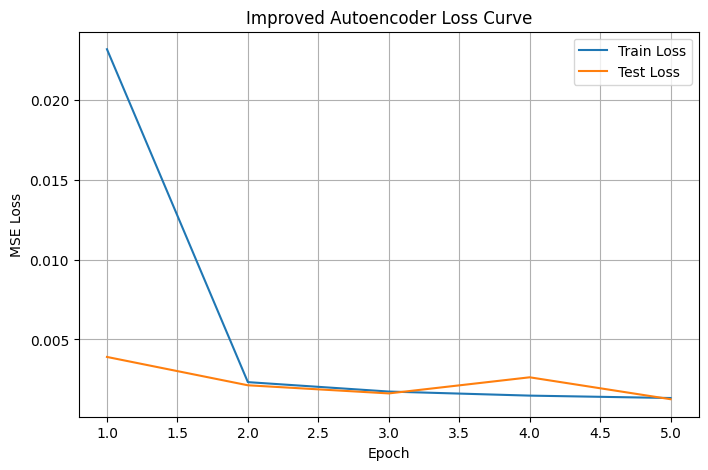

In [12]:
plot_loss_curves(
    improved_history,
    "Improved Autoencoder Loss Curve",
    "images/tutorial_12_improved_autoencoder_loss.png"
)


## 11. Visualize Improved Autoencoder Reconstructions

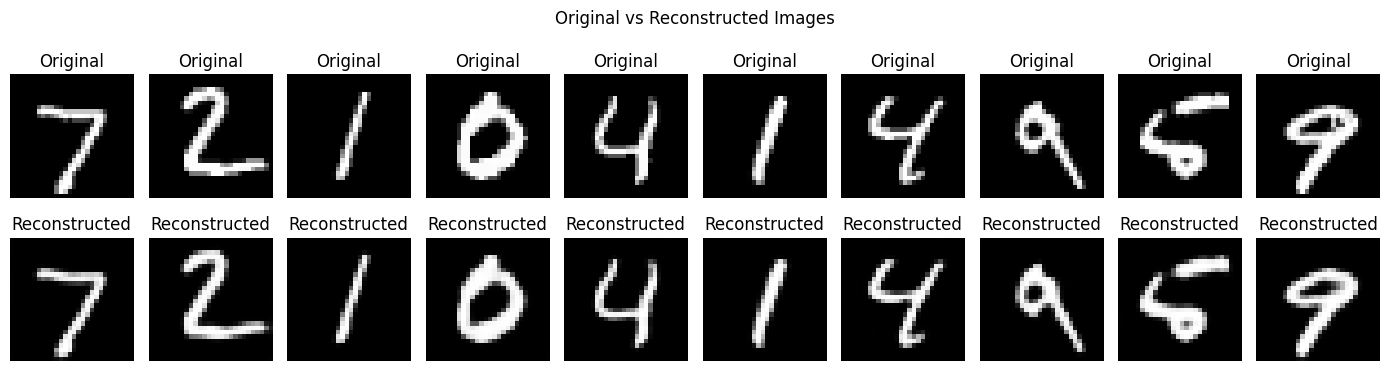

In [13]:
visualize_reconstructions(
    improved_model,
    test_dataset_used,
    filename="images/tutorial_12_improved_reconstructions.png",
    n_images=10
)


## 12. Compare Basic and Improved Autoencoders

In [14]:
comparison_df = pd.DataFrame([
    {
        "Model": "Basic Autoencoder",
        "Trainable Parameters": count_trainable_parameters(basic_model),
        "Final Train Loss": basic_history["train_loss"][-1],
        "Final Test Loss": basic_history["test_loss"][-1],
        "Training Time (s)": basic_time
    },
    {
        "Model": "Improved Autoencoder",
        "Trainable Parameters": count_trainable_parameters(improved_model),
        "Final Train Loss": improved_history["train_loss"][-1],
        "Final Test Loss": improved_history["test_loss"][-1],
        "Training Time (s)": improved_time
    }
])

comparison_df


,Model,Trainable Parameters,Final Train Loss,Final Test Loss,Training Time (s)
0,Basic Autoencoder,29249,0.003685,0.003528,16.681291
1,Improved Autoencoder,222561,0.001332,0.001256,19.833728


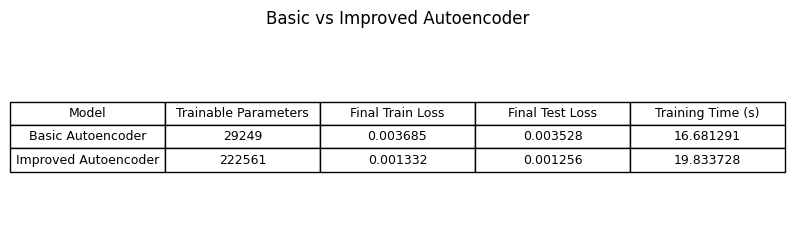

In [15]:
def save_dataframe_as_image(df, filename, title=None):
    fig_width = max(8, len(df.columns) * 2.0)
    fig_height = max(2.5, len(df) * 0.45 + 1.2)

    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    ax.axis("off")

    table = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        cellLoc="center",
        loc="center"
    )

    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 1.4)

    if title:
        ax.set_title(title, fontsize=12, pad=12)

    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()


comparison_image_df = comparison_df.copy()

for column in ["Final Train Loss", "Final Test Loss", "Training Time (s)"]:
    comparison_image_df[column] = comparison_image_df[column].round(6)

save_dataframe_as_image(
    comparison_image_df,
    "images/tutorial_12_model_comparison_table.png",
    title="Basic vs Improved Autoencoder"
)


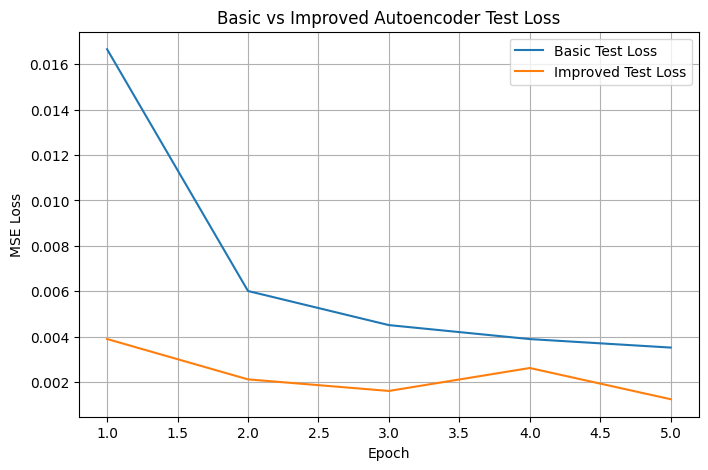

In [16]:
plt.figure(figsize=(8, 5))

plt.plot(range(1, len(basic_history["test_loss"]) + 1), basic_history["test_loss"], label="Basic Test Loss")
plt.plot(range(1, len(improved_history["test_loss"]) + 1), improved_history["test_loss"], label="Improved Test Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Basic vs Improved Autoencoder Test Loss")
plt.legend()
plt.grid(True)
plt.savefig("images/tutorial_12_basic_vs_improved_loss.png", dpi=300, bbox_inches="tight")
plt.show()


# Final Observations

## Basic Autoencoder

The basic autoencoder compressed the image using convolution and pooling layers and reconstructed it using transposed convolutions.

## Improved Autoencoder

The improved autoencoder used more layers and batch normalization.  
This increased the model capacity and helped improve reconstruction quality.

## Key Learning

Autoencoders learn to recreate the input image.  
The encoder compresses the image into a smaller representation, and the decoder reconstructs the original image from that representation.

A deeper architecture can improve reconstruction quality, but it also increases training time and the number of trainable parameters.
